# Model Evaluation
Goal: Validate Random Forest more rigorously using cross-validation, confusion matrix, and feature importance before finalizing it as the production model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

label_encoder = joblib.load('../models/label_encoder.pkl')

In [2]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [3]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")

Cross-validation scores: [0.99147727 0.99431818 0.99715909 0.99715909 0.98579545]
Mean CV accuracy: 0.9932
Std deviation: 0.0043


<Figure size 1400x1200 with 0 Axes>

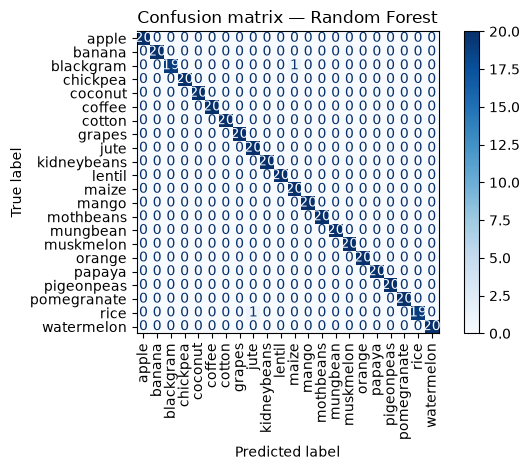

In [4]:
preds = model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=90, cmap='Blues', values_format='d')
plt.title('Confusion matrix — Random Forest')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()

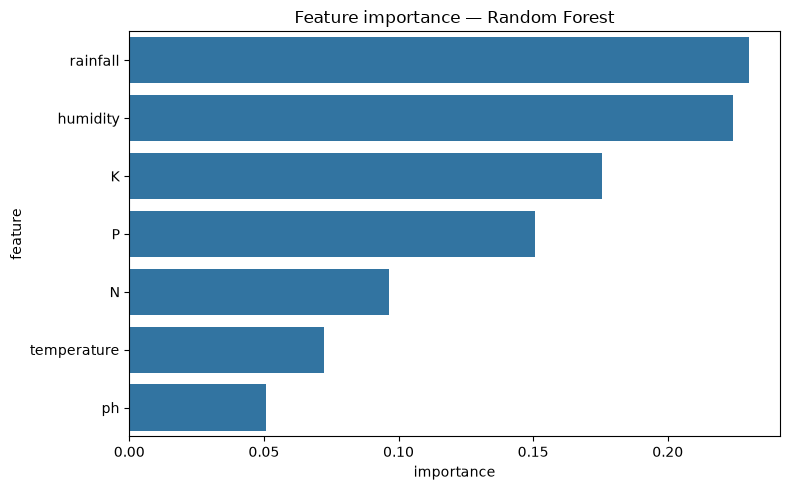

       feature  importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


In [5]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature importance — Random Forest')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png')
plt.show()

print(importance_df)

## Summary
- Cross-validation mean accuracy: 0.9932 (5-fold: 0.9915, 0.9943, 0.9972, 0.9972, 0.9858).
- Cross-validation std deviation: 0.0043 — very low, confirming the model is stable across different data splits, not just lucky on one split.
- Confusion matrix: near-perfect diagonal. Minor confusion only between blackgram/lentil (1 misclassified) and rice/jute (1 misclassified) — everything else classified perfectly across all 22 crops.
- Most important features: rainfall (0.230), humidity (0.224), and potassium/K (0.175) are the strongest predictors.
- Least important features: pH (0.051) and temperature (0.072) contribute the least, though still meaningfully.
- Random Forest confirmed as the final model for production, with default hyperparameters (n_estimators=100, max_depth=None) performing well without needing tuning.